# Regressão — Análise Exploratória (EDA)

**Objetivo:** prever o **PIB per capita** dos municípios brasileiros a partir de indicadores
populacionais e da composição setorial da economia local.

**Fonte dos dados:** IBGE — API de agregados (SIDRA), tabelas:
- [5938 — Produto Interno Bruto dos Municípios](https://sidra.ibge.gov.br/tabela/5938) (ano de referência 2021)
- [6579 — População residente estimada](https://sidra.ibge.gov.br/tabela/6579) (ano de referência 2021)

Os dados foram coletados com o script [`src/baixar_dados.py`](../src/baixar_dados.py) e salvos em `../data/pib_municipios.csv`.

**Dicionário de dados**

| Coluna | Descrição |
|---|---|
| `codigo_municipio` | Código IBGE do município |
| `municipio` | Nome do município |
| `uf` | Unidade da Federação (sigla) |
| `regiao` | Grande região do Brasil |
| `populacao` | População residente estimada (pessoas) |
| `participacao_agropecuaria` | % do VAB municipal proveniente da agropecuária |
| `participacao_industria` | % do VAB municipal proveniente da indústria |
| `participacao_servicos` | % do VAB municipal proveniente de serviços (excl. administração pública) |
| `participacao_administracao_publica` | % do VAB municipal proveniente da administração pública, defesa, educação e saúde públicas |
| `pib_per_capita` | **Alvo.** PIB per capita do município em R$ (PIB total / população) |

> **Nota sobre vazamento de dados:** esta é uma exploração sobre a base completa, só para entender o
> problema. Qualquer decisão de transformação (ex.: log do alvo, tratamento de outliers, encoding)
> será ajustada **somente nos dados de treino**, dentro do pipeline de modelagem (notebooks seguintes),
> para não vazar informação do teste.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')  # tema único para manter os gráficos consistentes entre os 4 notebooks
pd.set_option('display.max_columns', None)


## 2. Carregar os dados

In [2]:
df = pd.read_csv('../data/pib_municipios.csv')
print('Linhas x Colunas:', df.shape)
df.head()


Linhas x Colunas: (5570, 10)


,codigo_municipio,municipio,uf,regiao,populacao,participacao_agropecuaria,participacao_industria,participacao_servicos,participacao_administracao_publica,pib_per_capita
0,1100015,Alta Floresta D'Oeste,RO,Norte,22516,45.48,4.07,25.18,25.28,32619.781489
1,1100023,Ariquemes,RO,Norte,111148,10.50,14.61,46.86,28.03,28892.053838
2,1100031,Cabixi,RO,Norte,5067,60.14,3.57,15.78,20.50,47052.299191
3,1100049,Cacoal,RO,Norte,86416,14.17,9.83,49.86,26.13,32314.687095
4,1100056,Cerejeiras,RO,Norte,16088,24.82,4.49,50.51,20.19,46187.344605


## 3. Visão geral e qualidade dos dados

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   codigo_municipio                    5570 non-null   int64  
 1   municipio                           5570 non-null   object 
 2   uf                                  5570 non-null   object 
 3   regiao                              5570 non-null   object 
 4   populacao                           5570 non-null   int64  
 5   participacao_agropecuaria           5570 non-null   float64
 6   participacao_industria              5570 non-null   float64
 7   participacao_servicos               5570 non-null   float64
 8   participacao_administracao_publica  5570 non-null   float64
 9   pib_per_capita                      5570 non-null   float64
dtypes: float64(5), int64(2), object(3)
memory usage: 435.3+ KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
codigo_municipio,5570.0,NaN,NaN,NaN,3253590.770736,984910.339431,1100015.0,2512125.75,3146280.0,4119189.5,5300108.0
municipio,5570,5297,Bom Jesus,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uf,5570,27,MG,853,NaN,NaN,NaN,NaN,NaN,NaN,NaN
regiao,5570,5,Nordeste,1794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
populacao,5570.0,NaN,NaN,NaN,38297.601257,224288.152809,771.0,5454.0,11732.0,25764.75,12396372.0
participacao_agropecuaria,5570.0,NaN,NaN,NaN,23.889352,18.805818,-41.9,8.7425,19.01,36.31,93.5
participacao_industria,5570.0,NaN,NaN,NaN,14.089892,15.477564,0.48,4.16,7.07,18.5075,209.6
participacao_servicos,5570.0,NaN,NaN,NaN,31.644607,13.474413,-42.01,21.8225,29.215,39.59,89.84
participacao_administracao_publica,5570.0,NaN,NaN,NaN,30.376142,17.097898,-25.7,16.0025,26.77,43.9475,83.47
pib_per_capita,5570.0,NaN,NaN,NaN,33873.069525,41909.393167,5406.450671,12831.691759,23372.934863,40810.870685,920828.362306


In [5]:
# Valores nulos por coluna
nulos = df.isnull().sum().sort_values(ascending=False)
nulos[nulos > 0] if nulos.sum() > 0 else print('Sem valores nulos.')


Sem valores nulos.


In [6]:
print('Municípios duplicados:', df['codigo_municipio'].duplicated().sum())
print('Municípios únicos:', df['codigo_municipio'].nunique())
print('UFs cobertas:', df['uf'].nunique(), '/ 27')


Municípios duplicados: 0
Municípios únicos: 5570
UFs cobertas: 27 / 27


## 4. Distribuição do alvo (`pib_per_capita`)

C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


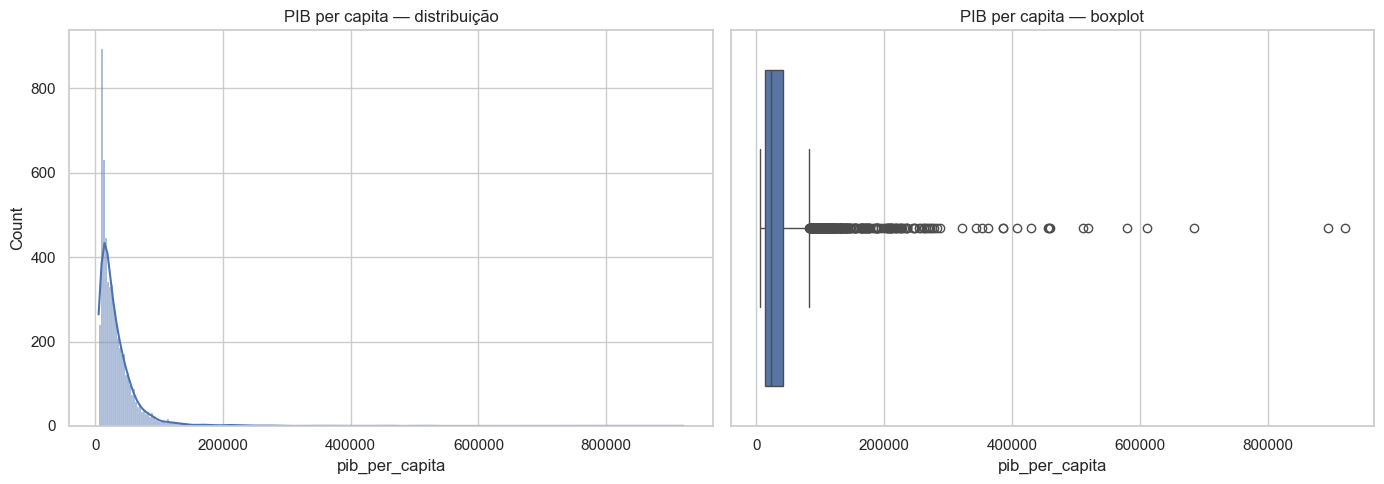

Assimetria (skew): 7.92


In [7]:
# histplot mostra a forma da distribuição; boxplot evidencia os outliers extremos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['pib_per_capita'], kde=True, ax=axes[0])
axes[0].set_title('PIB per capita — distribuição')
sns.boxplot(x=df['pib_per_capita'], ax=axes[1])
axes[1].set_title('PIB per capita — boxplot')
plt.tight_layout()
plt.savefig('../reports/01_distribuicao_alvo.png', dpi=120)  # salvo em reports/ para reaproveitar no README
plt.show()

print('Assimetria (skew):', df['pib_per_capita'].skew().round(2))


**Resultado:** assimetria (skew) ≈ **7,9** — bem acima do intervalo `[-1, 1]` considerado
"aproximadamente simétrico". O boxplot confirma: uma cauda longa de outliers acima do limite
superior, coerente com poucos municípios com PIB per capita muito alto (geralmente ligados a
petróleo/mineração/energia). **Escolha para os próximos notebooks:** esse skew é o principal
motivo para testar `log1p(pib_per_capita)` como alvo dos modelos lineares — fica registrado aqui
como hipótese, não como decisão já tomada, porque ainda não vimos como cada modelo reage a ela.

In [8]:
# investigar os extremos ajuda a checar se o skew é "ruído" no dado ou um padrão econômico real
df.nlargest(10, 'pib_per_capita')[['municipio', 'uf', 'populacao', 'pib_per_capita']]


,municipio,uf,populacao,pib_per_capita
2410,Catas Altas,MG,5465,920828.362306
183,Canaã dos Carajás,PA,39103,894762.933790
2965,São Gonçalo do Rio Abaixo,MG,11114,684163.037610
2624,Itatiaiuçu,MG,11354,610741.765017
3155,Presidente Kennedy,ES,11741,580174.005621
2435,Conceição do Mato Dentro,MG,17438,519036.185342
3215,Maricá,RJ,167668,511810.172484
3255,Saquarema,RJ,91938,458767.419348
3677,Paulínia,SP,114508,457517.701820
5205,Campos de Júlio,MT,7245,455824.844720


**Resultado:** os dez primeiros não são metrópoles — são municípios pequenos com atividade
industrial/mineradora concentrada. Os dois primeiros, **Catas Altas-MG** e **Canaã dos Carajás-PA**,
têm menos de 40 mil habitantes e PIB per capita acima de R$ 890 mil. Uma população pequena
dividindo um PIB setorial concentrado é exatamente o mecanismo que gera a cauda longa do
histograma acima — não é erro de dado, é geografia econômica real (mineração, no caso).

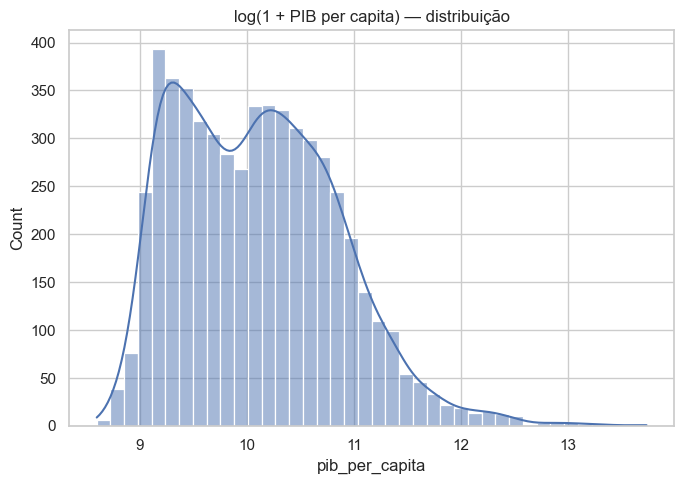

In [9]:
# como fica a distribuição em escala log — testa a hipótese levantada na célula anterior
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(np.log1p(df['pib_per_capita']), kde=True, ax=ax)
ax.set_title('log(1 + PIB per capita) — distribuição')
plt.tight_layout()
plt.savefig('../reports/02_distribuicao_alvo_log.png', dpi=120)
plt.show()


**Resultado:** em log, a distribuição fica bem mais próxima de uma normal, sem a cauda longa de
antes. É a confirmação visual de que `log1p(pib_per_capita)` é uma transformação candidata forte
para os modelos lineares — modelos baseados em árvore (Random Forest, XGBoost) são invariantes a
essa transformação monotônica, então essa escolha importa mais para uns modelos que para outros.

## 5. Distribuições das variáveis numéricas

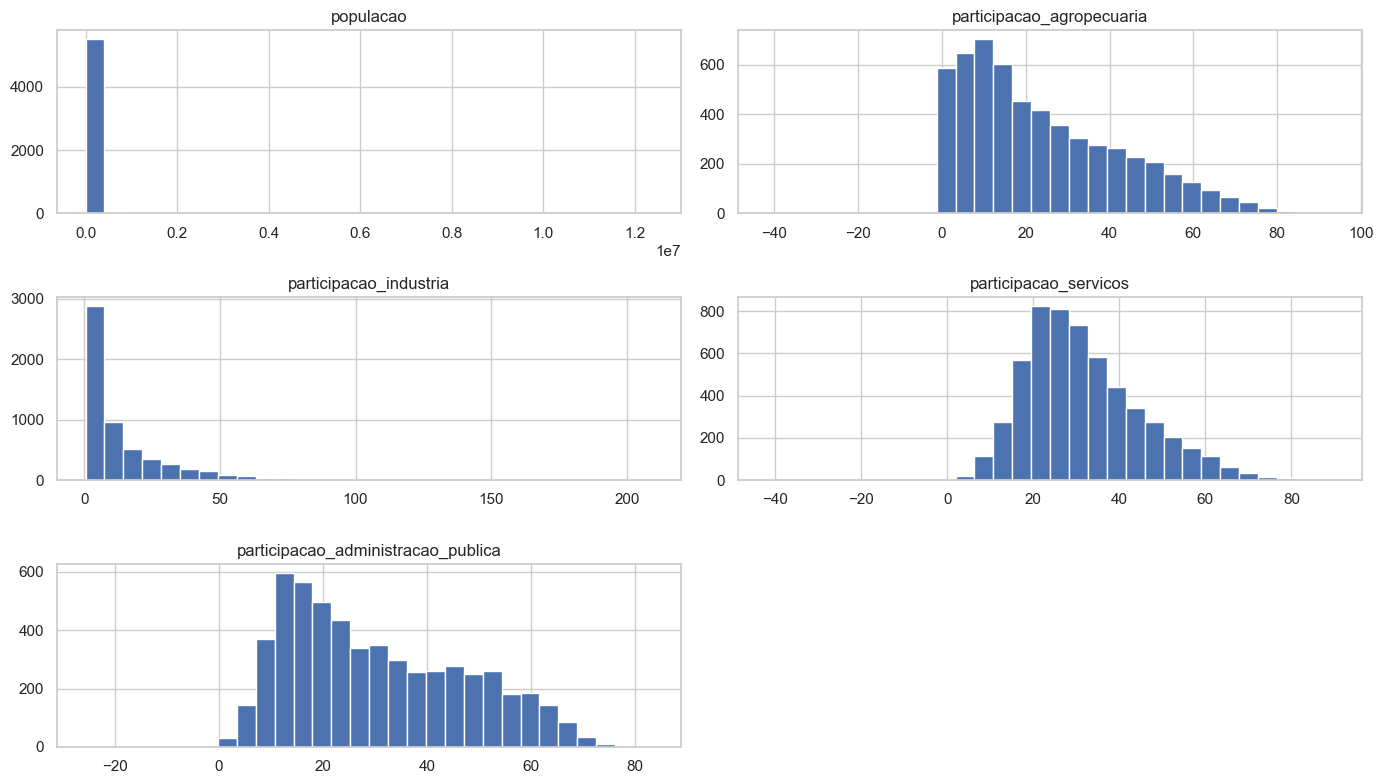

In [10]:
num_cols = ['populacao', 'participacao_agropecuaria', 'participacao_industria',
            'participacao_servicos', 'participacao_administracao_publica']
# olhar a forma de cada feature antes de decidir sobre escalonamento/transformação nos notebooks seguintes
df[num_cols].hist(figsize=(14, 8), bins=30)
plt.tight_layout()
plt.savefig('../reports/03_distribuicoes_features.png', dpi=120)
plt.show()


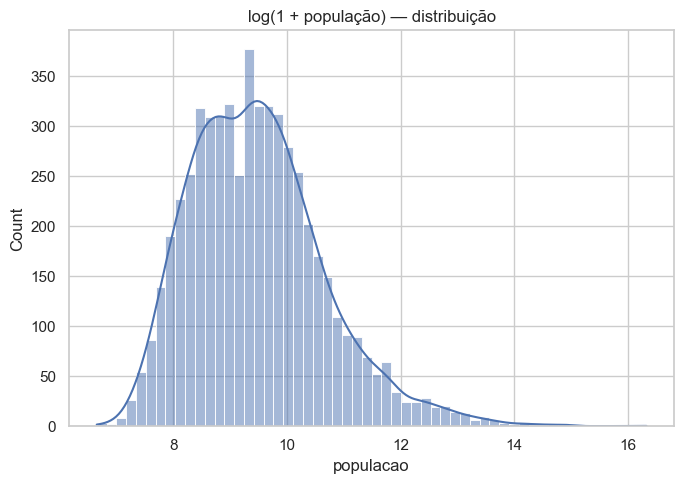

In [11]:
# populacao também é bem assimétrica (poucas metrópoles, muitos municípios pequenos) — mesmo padrão do alvo
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(np.log1p(df['populacao']), kde=True, ax=ax)
ax.set_title('log(1 + população) — distribuição')
plt.tight_layout()
plt.show()


## 6. Variáveis categóricas (`uf`, `regiao`)

C:\Users\edd-j\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


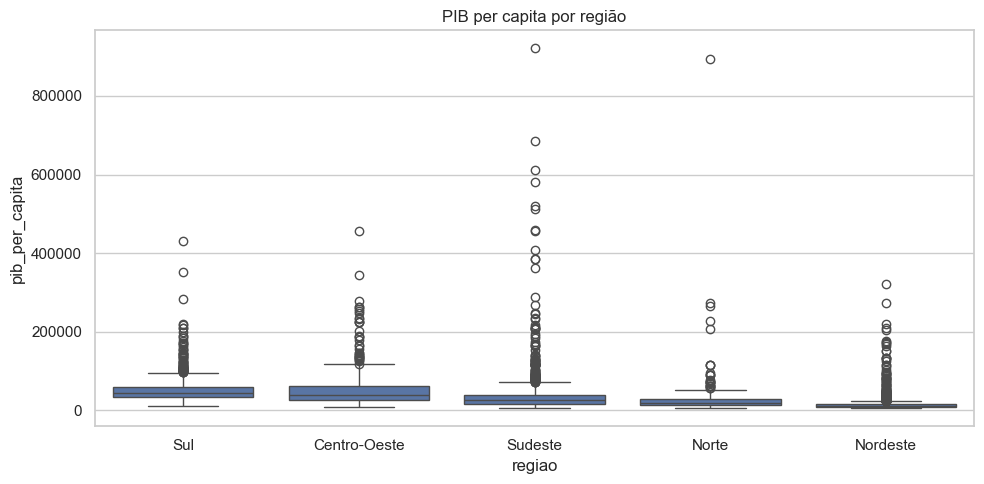

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
# ordena pela mediana (não pela média) para não deixar os outliers de mineração distorcerem o ranking visual
sns.boxplot(data=df, x='regiao', y='pib_per_capita', ax=ax,
            order=df.groupby('regiao')['pib_per_capita'].median().sort_values(ascending=False).index)
ax.set_title('PIB per capita por região')
plt.tight_layout()
plt.savefig('../reports/04_pib_per_capita_por_regiao.png', dpi=120)
plt.show()


**Resultado (contraintuitivo):** o **Sul** tem a maior mediana de PIB per capita (R$ 43 mil),
à frente do Centro-Oeste (R$ 38 mil) e — surpreendentemente — do **Sudeste** (R$ 25 mil), que é
onde ficam São Paulo e Rio de Janeiro. Norte e Nordeste ficam bem abaixo (R$ 18 mil e R$ 11 mil).
A explicação provável: o Sudeste tem poucas metrópoles gigantes puxando a *média* para cima, mas a
*mediana* reflete a base ampla de municípios menores, onde o Sul tem uma economia industrial/agro
mais distribuída. **Por que isso importa para a modelagem:** confirma que `uf`/`regiao` carregam
sinal real (não é ruído) e devem entrar no modelo como features categóricas.

In [13]:
df.groupby('regiao')['pib_per_capita'].agg(['count', 'median', 'mean', 'std']).sort_values('median', ascending=False)


,count,median,mean,std
regiao,,,,
Sul,1191,43021.856582,50451.246777,31159.757949
Centro-Oeste,467,38486.435043,54416.910615,50315.846036
Sudeste,1668,25312.166813,37002.016204,52172.650703
Norte,450,18601.921796,27364.973038,48768.559301
Nordeste,1794,11499.201485,16242.622180,20085.071982


## 7. Correlações entre variáveis numéricas

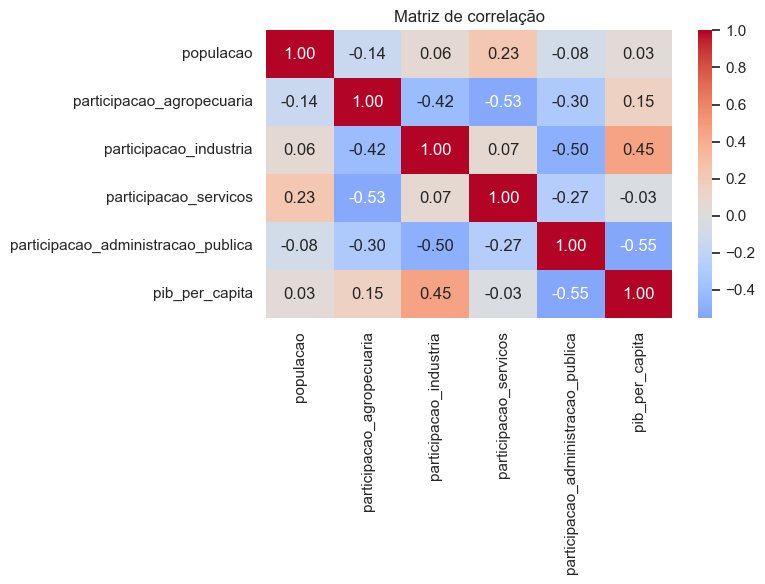

In [14]:
corr_cols = num_cols + ['pib_per_capita']
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlação')
plt.tight_layout()
plt.savefig('../reports/05_matriz_correlacao.png', dpi=120)
plt.show()


**Resultado:** correlação de cada feature com `pib_per_capita`, do mais forte ao mais fraco:

| Feature | Correlação |
|---|---:|
| `participacao_industria` | **+0,45** |
| `participacao_agropecuaria` | +0,15 |
| `populacao` | +0,03 |
| `participacao_servicos` | −0,03 |
| `participacao_administracao_publica` | **−0,55** |

Dois pontos chamam atenção:
- **`populacao` tem correlação linear ≈ 0** — não significa que população é irrelevante, e sim que a
  relação provavelmente não é linear (municípios médios podem ter PIB per capita tão alto quanto
  metrópoles, dependendo do setor). Isso é um argumento a favor de modelos baseados em árvore, que
  capturam não-linearidades sem precisar que a gente as especifique.
- **`participacao_administracao_publica` é a correlação mais forte, e é negativa.** Faz sentido
  economicamente: municípios pequenos com pouca atividade privada dependem da máquina pública
  (prefeitura, escolas, saúde) como principal empregador — e esses tendem a ser os mais pobres per capita.

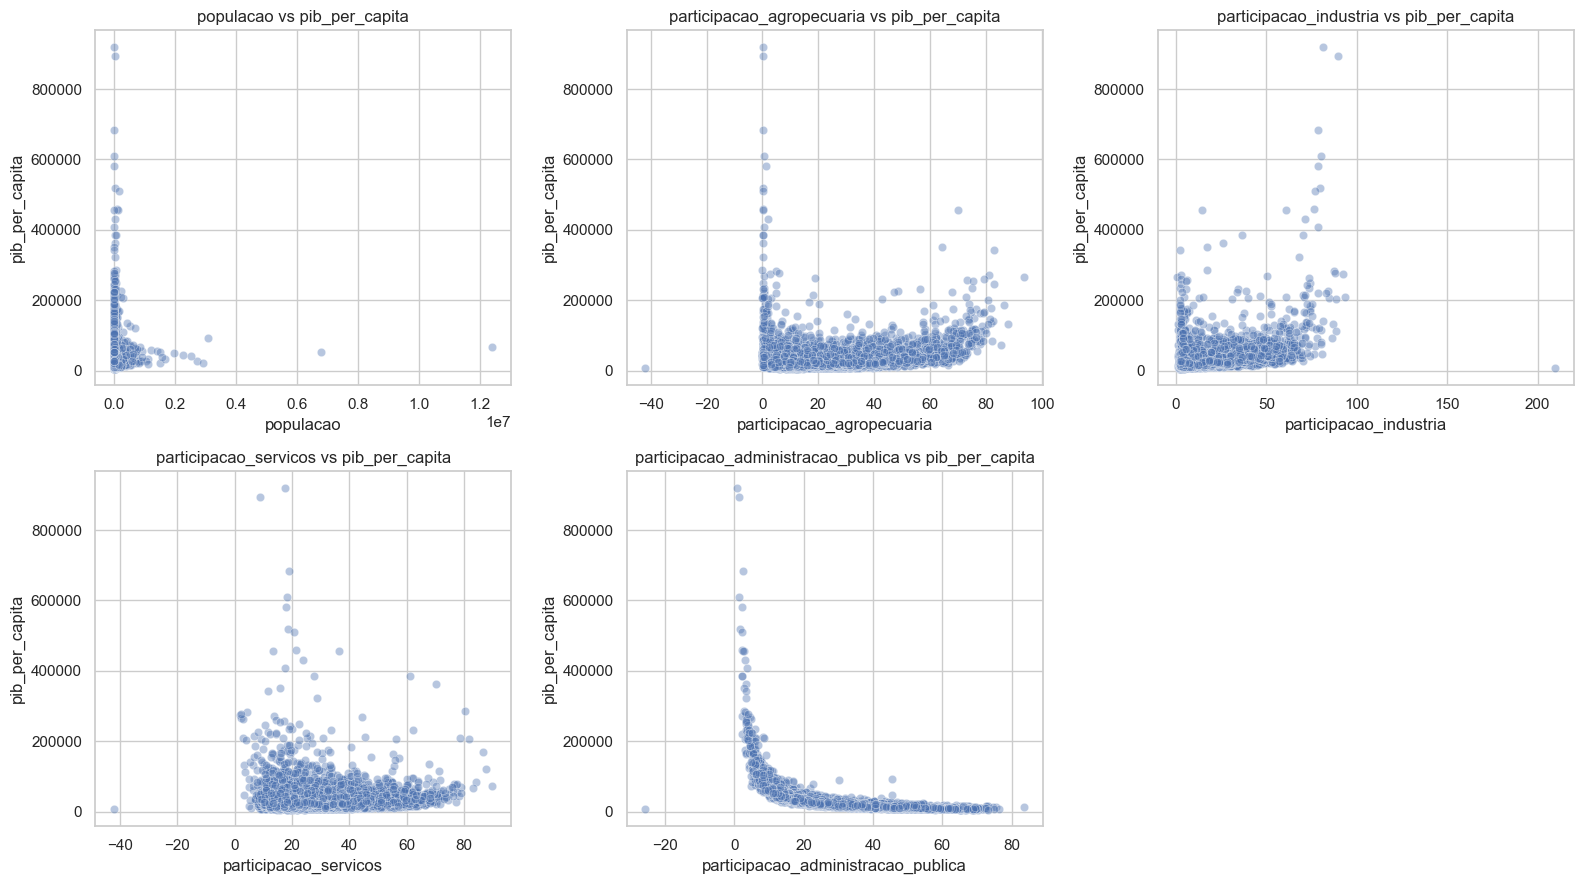

In [15]:
# dispersão feature a feature — checagem visual da correlação da tabela acima, e de possíveis não-linearidades
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, ax in zip(num_cols, axes.ravel()):
    sns.scatterplot(data=df, x=col, y='pib_per_capita', alpha=0.4, ax=ax)
    ax.set_title(f'{col} vs pib_per_capita')
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.savefig('../reports/06_dispersao_features_vs_alvo.png', dpi=120)
plt.show()


**Resultado:** os gráficos confirmam a tabela de correlação, mas mostram algo que ela esconde —
a maior parte dos pontos com PIB per capita muito alto está concentrada em valores baixos/médios de
`populacao`, reforçando a leitura da célula 14 (municípios pequenos com economia concentrada). Em
`participacao_industria` dá para ver uma tendência de alta mais clara à direita do gráfico, enquanto
`participacao_administracao_publica` mostra o oposto — os pontos mais altos do alvo se concentram
onde essa participação é baixa.

## 8. Conclusões da EDA

- O alvo (`pib_per_capita`) é contínuo e fortemente assimétrico (skew ≈ 7,9) — `log1p` é uma
  transformação candidata a testar nos modelos lineares.
- `populacao` tem correlação linear quase nula (0,03) com o alvo — sinal de que a relação não é
  linear, o que favorece modelos baseados em árvore (Random Forest, XGBoost) sobre regressão linear.
- `participacao_administracao_publica` (−0,55) e `participacao_industria` (+0,45) são as features
  numéricas mais associadas ao alvo — municípios mais dependentes do setor público tendem a ser
  mais pobres per capita; municípios mais industrializados, mais ricos.
- `uf`/`regiao` carregam sinal real: o Sul lidera em mediana de PIB per capita, à frente até do
  Sudeste — um resultado que contraria a intuição de que São Paulo/Rio "puxam" a região mais rica.
- Não há valores nulos nem duplicados a tratar — a base já chega pronta para separar treino/teste.

**Próximos passos:** `02_Baseline.ipynb` (split treino/teste + pipeline + modelos simples).
